В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
import sys
sys.path.append('/content/drive/My Drive/ML_homework')

In [38]:
from process_bank_churn import preprocess_data

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [40]:
raw_df = pd.read_csv('/content/drive/MyDrive/ML_homework/Датасети/Bank Customer Churn Prediction (DLU Course c.3)/train.csv')

In [41]:
data = preprocess_data(raw_df, scale_numeric=True)

In [42]:
X_train = data['X_train']
train_targets = data['train_targets']
X_val = data['X_val']
val_targets = data['val_targets']

1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [43]:
knn = KNeighborsClassifier()

In [44]:
knn.fit(X_train, train_targets)

KNeighborsClassifier()

In [45]:
def compute_auroc_and_build_roc(model, inputs, targets, name=''):
  # Predict probabilities
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    # Compute AUROC
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')

  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

AUROC for Training: 0.95


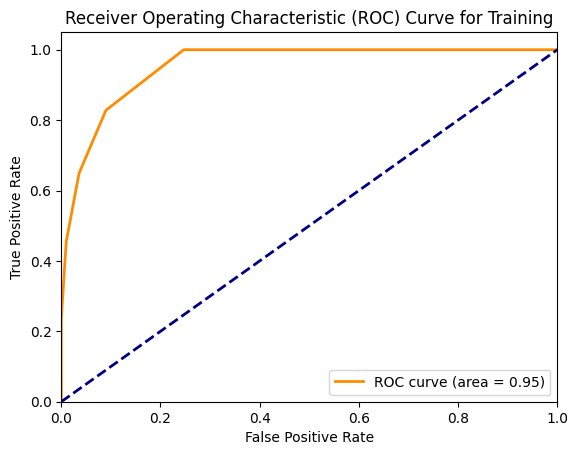

AUROC for Validation: 0.86


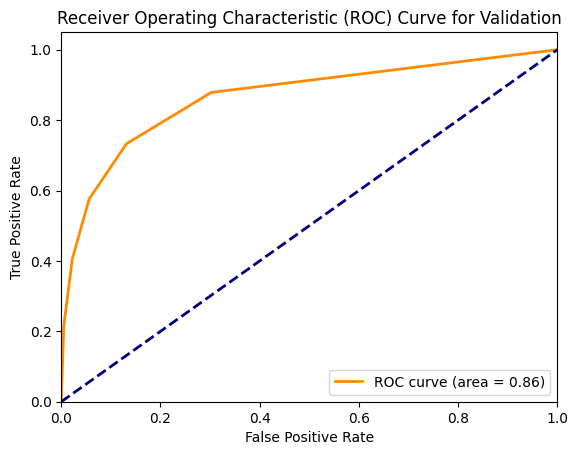

In [46]:
compute_auroc_and_build_roc(knn, X_train, train_targets, 'Training')
compute_auroc_and_build_roc(knn, X_val, val_targets, 'Validation')

**Висновок**

Модель є хорошою, але присутня варіативність, так як вона добре спрацювала на навчальному наборі даних і помітно гірше на валідаційному, хоча AUROC 0.86 також досить хороший показник

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [47]:
parameters = {
    'n_neighbors': np.arange(1, 31)
}

In [48]:
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=parameters,
    cv=5
)

In [49]:
grid_search.fit(X_train, train_targets)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])})

In [50]:
grid_search.best_params_, grid_search.best_score_

({'n_neighbors': np.int64(7)}, np.float64(0.866))

In [51]:
knn_best = KNeighborsClassifier(n_neighbors=7)

In [52]:
knn_best.fit(X_train, train_targets)

KNeighborsClassifier(n_neighbors=7)

AUROC for Training: 0.95


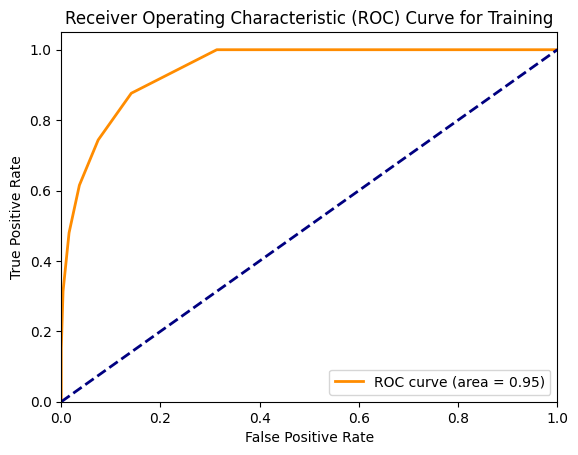

AUROC for Validation: 0.88


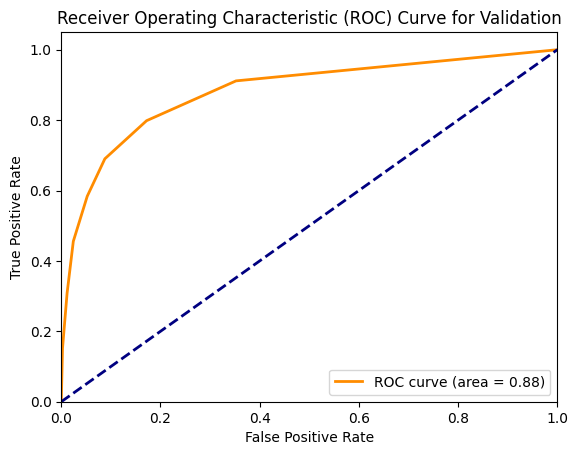

In [53]:
compute_auroc_and_build_roc(knn_best, X_train, train_targets, 'Training')
compute_auroc_and_build_roc(knn_best, X_val, val_targets, 'Validation')

Якість моделі покращилася, модель стала трішки краще узагальнювати і працювати з даними яких вона не бачила

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [54]:
dt_parameters = {
    'max_depth': np.arange(1, 21, 2),
    'max_leaf_nodes': np.arange(2, 11, 1)
}

In [55]:
dt_parameters

{'max_depth': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
 'max_leaf_nodes': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10])}

In [56]:
dt = DecisionTreeClassifier()

In [57]:
dt_grid_search = GridSearchCV(
    estimator=dt,
    param_grid=dt_parameters,
    cv=3,
    scoring='roc_auc'
)

In [58]:
%%time

dt_grid_search.fit(X_train, train_targets)

CPU times: user 6.04 s, sys: 16.5 ms, total: 6.06 s
Wall time: 6.27 s


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                         'max_leaf_nodes': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10])},
             scoring='roc_auc')

In [59]:
dt_grid_search.best_params_, dt_grid_search.best_score_

({'max_depth': np.int64(5), 'max_leaf_nodes': np.int64(10)},
 np.float64(0.8985077784512813))

In [60]:
dt_best = DecisionTreeClassifier(max_depth=5, max_leaf_nodes=10)

In [61]:
dt_best.fit(X_train, train_targets)

DecisionTreeClassifier(max_depth=5, max_leaf_nodes=10)

AUROC for Training: 0.90


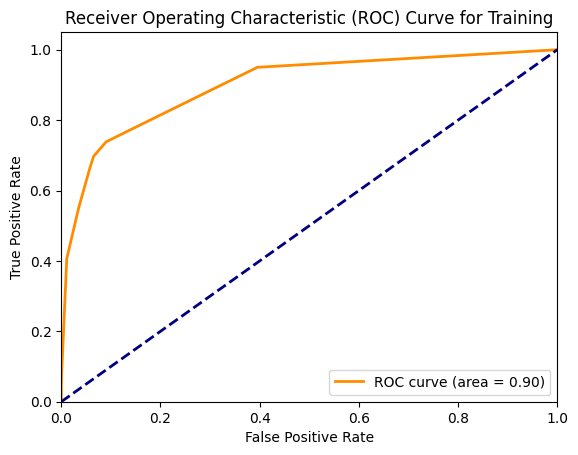

AUROC for Validation: 0.90


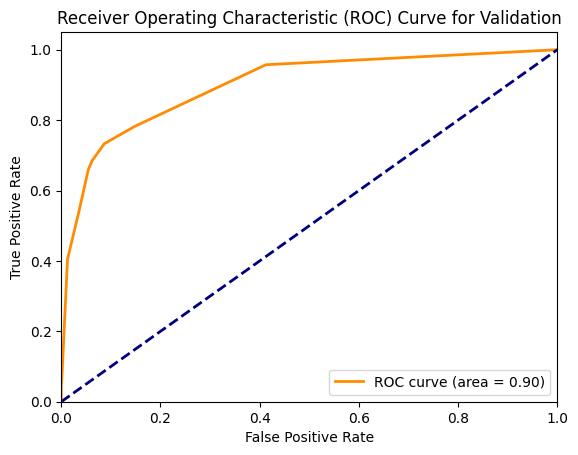

In [62]:
compute_auroc_and_build_roc(dt_best, X_train, train_targets, 'Training')
compute_auroc_and_build_roc(dt_best, X_val, val_targets, 'Validation')

Хоч і значення метрики AUROC для тренувального набору знизилося, але модель стала збалансованою, усунуто варіативність, зросла якість на нових даних

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [63]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [64]:
dt_randon_search = RandomizedSearchCV(
    dt,
    params_dt,
    n_iter=40,
    cv=3,
    scoring='roc_auc',
    random_state = 17
)

In [65]:
%%time

dt_randon_search.fit(X_train, train_targets)

CPU times: user 1.78 s, sys: 5.95 ms, total: 1.79 s
Wall time: 1.79 s


RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_iter=40,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'max_leaf_nodes': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19]),
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'splitter': ['best', 'random']},
                   random_state=17, scoring='roc_auc')

In [66]:
dt_randon_search.best_params_, dt_randon_search.best_score_

({'splitter': 'best',
  'min_samples_split': 2,
  'min_samples_leaf': 2,
  'max_leaf_nodes': np.int64(16),
  'max_features': None,
  'max_depth': np.int64(12),
  'criterion': 'gini'},
 np.float64(0.9111183602709026))

In [67]:
dt_random_search_best = DecisionTreeClassifier(splitter='best', min_samples_split=2, min_samples_leaf=2, max_leaf_nodes=16, max_features=None, max_depth=12, criterion='gini')

In [68]:
dt_random_search_best.fit(X_train, train_targets)

DecisionTreeClassifier(max_depth=12, max_leaf_nodes=16, min_samples_leaf=2)

AUROC for Training: 0.91


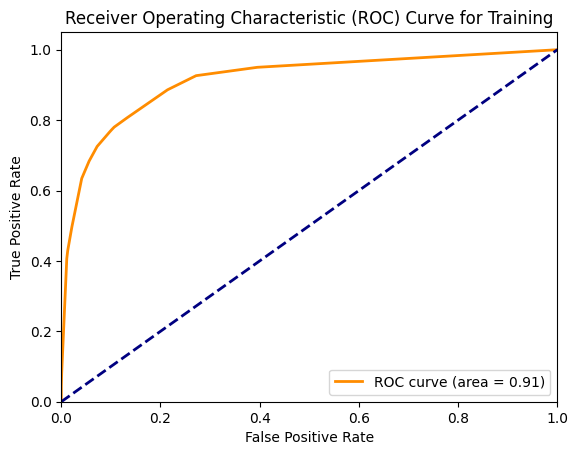

AUROC for Validation: 0.91


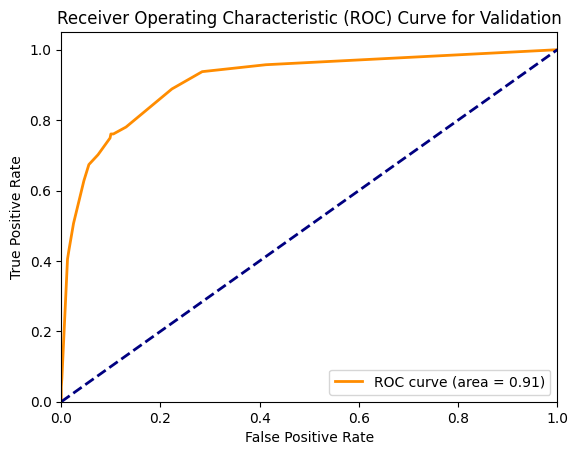

In [69]:
compute_auroc_and_build_roc(dt_random_search_best, X_train, train_targets, 'Training')
compute_auroc_and_build_roc(dt_random_search_best, X_val, val_targets, 'Validation')

Метрика AUROC ще трішки покращилася, модель залишилася такою ж збалансованою, а також час на пошук оптимальних гіперпараметрів при використанні RandomizedSearchCV зменшився порівняно з GridSearchCV

5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

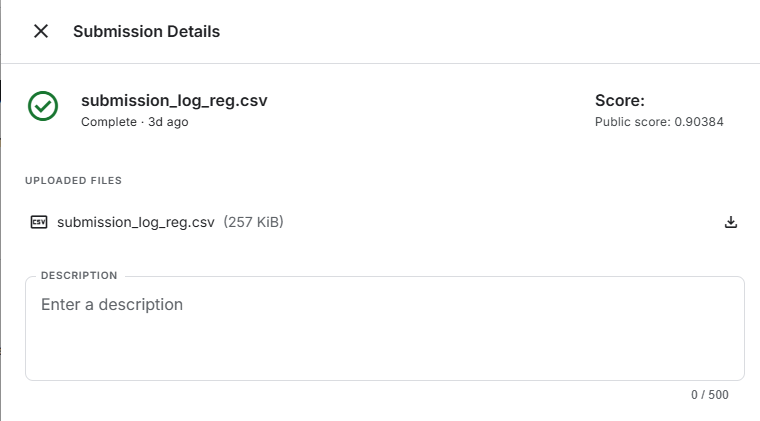